<a href="https://colab.research.google.com/github/eduardozurek/ia/blob/main/_007_aprendizaje_supervisado/_006_04_Clasificador_KNN_GridSearch_Cuatro_Categor%C3%ADas_Distancia_Euclidiana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificador basado en K Vecinos más Cercanos

Este es un algoritmo de aprendizaje supervisado, pero no hay parametros que ajustar. La clasificación se basa en la relación existente entre los datos que se van a clasificar y los datos de referencia. En este algoritmo no hay un proceso de entrenamiento. Se usan todos los datos de referencia siempre.

La relación entre los datos se establece teniendo en cuenta la distancia entre ellos. La distancia se mide usando las características, cada característica es una dimensión diferente. Las propiedades de las características de los datos determinan que funciones se pueden utilizar para medir la distancia.

En este ejemplo usaremos los datos de diferenciación niños/adultos usando estatura y peso, y aplicaremos distancia euclidiana.

In [ ]:
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import GridSearchCV


Text(0, 0.5, 'Peso en kilogramos')

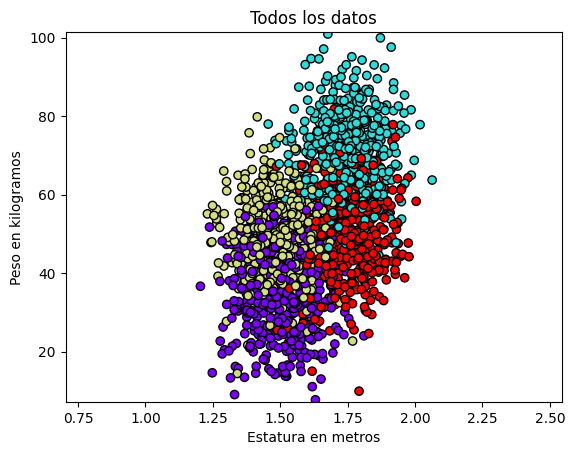

In [ ]:
X, y = make_blobs(n_samples=[500,500,500,500],
                  n_features = 4,
                  centers=[[1.50,35],[1.75,70],[1.50,50],[1.75,50]],
                  cluster_std = [[0.1,10],[0.1,10],[0.1,10],[0.1,10]],
                  random_state=1970)
y = y+1.0
x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
h = 0.02  # step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                      np.arange(y_min, y_max, h))

# just plot the dataset first
cm = plt.cm.rainbow
cm_bright = cm
#cm_bright = ListedColormap(['#FF0000', '#0000FF','#0FF000', '#000000'])
ax = plt.figure()
plt.title("Todos los datos")
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cm_bright,
            edgecolors='k')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xlabel("Estatura en metros")
plt.ylabel("Peso en kilogramos")


El ejemplo lo basaremos en datos simulados que representan\
una población de personas de género masculino\
niños y adultos, y se tienen dos características de ellos: estatura y peso

Dado que las escalas de peso y estaturas son muy diferentes
(dos ordenes de magnitud)
Antes de aplicar el clasificador, debemos llevarlas
a la misma escala:
* Se resta la media
* Se divide por la desviación estándar


In [ ]:
from sklearn import preprocessing
#X_estandarizada = X
X_estandarizada = preprocessing.scale(X)
X = X_estandarizada

Y volvemos a mostrar los datos ...

Text(0, 0.5, 'Peso en kilogramos')

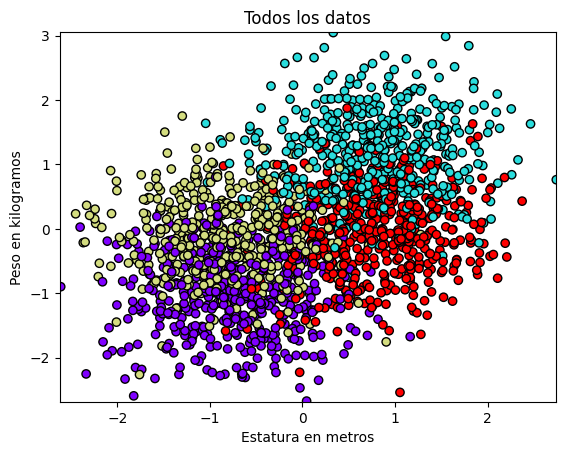

In [ ]:
x_min, x_max = X[:, 0].min() - .01, X[:, 0].max() + .01
y_min, y_max = X[:, 1].min() - .01, X[:, 1].max() + .01
h = 0.02  # step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                      np.arange(y_min, y_max, h))

# just plot the dataset first
#cm = plt.cm.RdBu
#cm_bright = ListedColormap(['#FF0000', '#0000FF','#0FF000', '#000000'])
ax = plt.figure()
plt.title("Todos los datos")
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cm_bright,
            edgecolors='k')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xlabel("Estatura en metros")
plt.ylabel("Peso en kilogramos")

Ahora creamos los datos de prueba y entrenamiento

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.33, random_state=1970)

In [ ]:
from sklearn import neighbors
clfKNN = neighbors.KNeighborsClassifier(n_neighbors=55, # número de vecinos
                                        weights='uniform', # pesos asignados a los vecinos al momento
                                                           # de tomar la decisión
                                                           # 'uniform', 'distance'
                                        algorithm='brute', # optimiza la ejecución del clasificador
                                                           # ‘auto’, ‘ball_tree’, ‘kd_tree’, ‘brute’
                                        p=2, # usado para la fórmula de la distancia de Minkowski
                                        metric='minkowski')
clfKNN.fit(X_train,y_train)
y_esperado = y_test
y_predicho = clfKNN.predict(X_test)

In [ ]:
clfKNN01 = neighbors.KNeighborsClassifier(n_neighbors=55, # número de vecinos
                                        weights='uniform', # pesos asignados a los vecinos al momento
                                                           # de tomar la decisión
                                                           # 'uniform', 'distance'
                                        algorithm='brute', # optimiza la ejecución del clasificador
                                                           # ‘auto’, ‘ball_tree’, ‘kd_tree’, ‘brute’
                                        p=2, # usado para la fórmula de la distancia de Minkowski
                                        metric='minkowski')
params = {'n_neighbors': [55,65,75,85,95,105]}
search = GridSearchCV(clfKNN01, params, cv=3, scoring='accuracy')
search.fit(X, y)
print("Best hyperparameters:", search.best_params_)
print("Best score:", search.best_score_)

Best hyperparameters: {'n_neighbors': 75}
Best score: 0.7305108706907807


In [ ]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_esperado,y_predicho))

0.7151515151515152


Como se puede ver, el sistema es capaz de clasificar\
correctamente mas del 90% de los datos de prueba

(77472, 4)


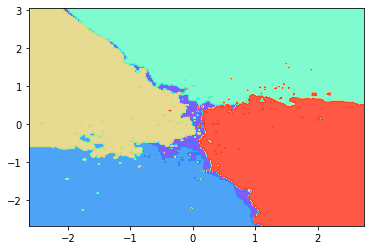

In [ ]:
ZT =clfKNN.predict_proba(np.c_[xx.ravel(), yy.ravel()])
print(ZT.shape)
ZT[ZT<0.5]=0.0
ZT[ZT>=0.5]=1.0
ZT[:, 1]=ZT[:, 1]*2.0
ZT[:, 2]=ZT[:, 2]*3.0
ZT[:, 3]=ZT[:, 3]*4.0
Z = ZT[:, 0]+ZT[:, 1]+ZT[:, 2]+ZT[:, 3]
# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.figure()
plt.contourf(xx, yy, Z, cmap=cm, alpha=.8)

Y esto es lo que el sistema sabe